## 🏷️OBJETIVO DEL PRESENTE CUADERNO (MODELADO)

¿Dónde estamos metidos?

En el Cuaderno 1 (EDA) limpia la mina y extrae el carbón bruto (los datos).

El Cuaderno 2 (Preproceso) actúa como la Planta de Saneamiento y Moldeado, transformando ese carbón en briquetas perfectas y estandarizadas (las 44 columnas que alimentan la línea).

El Cuaderno 3 es la Estación de Pruebas de Motores. 

Aquí tomamos esa materia prima saneada y se la entregamos a diferentes "motores" (algoritmos: XGBoost, Random Forest, Regresión Logística) para ver cuál es el más inteligente prediciendo si un cliente va a comprar (1) o no (0).

## 🎯 1. MODELADO PREDICTIVO - INGESTIÓN CON GOBIERNO DE DATOS

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# =====================================================================
# FASE 4: MODELADO PREDICTIVO - INGESTIÓN CON GOBIERNO DE DATOS
# =====================================================================

print("="*60)
print("📥 CONSUMIENDO MATERIA PRIMA DESDE LA CAPA OPERATIVA (PARQUET)")
print("="*60)

# 1. ENRUTAMIENTO ESTÁNDAR DE DATOS PROCESADOS
RUTA_DATOS_PROCESADOS = "../data/processed/"

# 2. CARGA DE ALTA EFICIENCIA (Preservando tipos de datos estrictos)
X_train = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "X_train_saneado.parquet"))
X_test = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "X_test_saneado.parquet"))

# Cargamos las variables objetivo y aplicamos .squeeze() para transformarlas en Series de Pandas
y_train = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "y_train.parquet")).squeeze()
y_test = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "y_test.parquet")).squeeze()

# 3. VERIFICACIÓN Y AUDITORÍA DE ENTRADA (No asumimos, validamos hechos)
print("🔬 REPORTE DE GOBIERNO DE DATOS - INGESTIÓN DE MODELADO")
print("="*60)
print(f"✔️ Matriz de Entrenamiento Predictora (X_train) : {X_train.shape[0]:,} filas × {X_train.shape[1]} columnas")
print(f"✔️ Matriz de Test Predictora (X_test)           : {X_test.shape[0]:,} filas × {X_test.shape[1]} columnas")
print(f"✔️ Variable Objetivo de Entrenamiento (y_train)  : {y_train.shape[0]:,} registros")
print(f"✔️ Variable Objetivo de Test (y_test)           : {y_test.shape[0]:,} registros")
print("-" * 60)
print(f"💡 [HECHO]: Datos validados. El universo predictivo cuenta con las {X_train.shape[1]} variables estratégicas.")
print("="*60)

📥 CONSUMIENDO MATERIA PRIMA DESDE LA CAPA OPERATIVA (PARQUET)
🔬 REPORTE DE GOBIERNO DE DATOS - INGESTIÓN DE MODELADO
✔️ Matriz de Entrenamiento Predictora (X_train) : 80,000 filas × 44 columnas
✔️ Matriz de Test Predictora (X_test)           : 20,000 filas × 44 columnas
✔️ Variable Objetivo de Entrenamiento (y_train)  : 80,000 registros
✔️ Variable Objetivo de Test (y_test)           : 20,000 registros
------------------------------------------------------------
💡 [HECHO]: Datos validados. El universo predictivo cuenta con las 44 variables estratégicas.


In [2]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn seaborn

## 🛠️ 2. (Motores de fábrica): Baseline Evaluation Phase (Fase de Evaluación de Línea Base). 

Objetivo es medir el rendimiento mínimo de los algoritmos puros sin asistencia externa.

🚀 INICIANDO 1ª CARRERA: AUDITORÍA PREDICTIVA DE LÍNEA BASE (BASELINE)
📋 VERIFICACIÓN DE ARQUITECTURA DE HIPERPARÁMETROS DE ENTRADA (BASELINE):
⚙️ Algoritmo Activo: Regresión Logística (Baseline) -> Parámetros cargados listos.
⚙️ Algoritmo Activo: Árbol de Decisión -> Parámetros cargados listos.
⚙️ Algoritmo Activo: Random Forest (Ensemble) -> Parámetros cargados listos.
⚙️ Algoritmo Activo: XGBoost (Gradient Boosting) -> Parámetros cargados listos.
⚙️ Algoritmo Activo: Gaussian Naive Bayes (Probabilístico) -> Parámetros cargados listos.
⚙️ Algoritmo Activo: K-Nearest Neighbors (Distancias) -> Parámetros cargados listos.
--------------------------------------------------------------------------------
🏋️‍♂️ Entrenando y extrayendo métricas base de: Regresión Logística (Baseline)...
🏋️‍♂️ Entrenando y extrayendo métricas base de: Árbol de Decisión...
🏋️‍♂️ Entrenando y extrayendo métricas base de: Random Forest (Ensemble)...
🏋️‍♂️ Entrenando y extrayendo métricas base de: XGBoost (Gradien

,Modelo/Algoritmo,Accuracy (General),Precision (Calidad Alerta),Recall (Captura/Ventas),F1-Score (Equilibrio),AUC-ROC (Separación)
0,Regresión Logística (Baseline),0.7044,0.1795,0.4758,0.2606,0.6445
1,Árbol de Decisión,0.6579,0.1683,0.5388,0.2565,0.6359
2,Random Forest (Ensemble),0.6821,0.1808,0.5393,0.2708,0.6787
3,XGBoost (Gradient Boosting),0.8922,0.7160,0.0265,0.0511,0.7344
4,Gaussian Naive Bayes (Probabilístico),0.7859,0.1554,0.2155,0.1806,0.5835
5,K-Nearest Neighbors (Distancias),0.8893,0.4808,0.1315,0.2065,0.6721



🧩 REPORTE DE GOBIERNO: ESTRUCTURA CUANTITATIVA DE ERRORES (ESTÁNDAR INDUSTRIAL):

🗂️ Regresión Logística (Baseline):
   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: 13,046 No Compras (65.23%) | FP: 4,764 Alertas Falsas (23.82%)
   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: 1,148 Ventas Perdidas (5.74%) | TP: 1,042 Compras Reales (5.21%)
--------------------------------------------------------------------------------

🗂️ Árbol de Decisión:
   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: 11,978 No Compras (59.89%) | FP: 5,832 Alertas Falsas (29.16%)
   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: 1,010 Ventas Perdidas (5.05%) | TP: 1,180 Compras Reales (5.90%)
--------------------------------------------------------------------------------

🗂️ Random Forest (Ensemble):
   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: 12,460 No Compras (62.30%) | FP: 5,350 Alertas Falsas (26.75%)
   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: 1,009 Ventas Perdidas (5.04%) | TP: 1,181 Compras Reales (5.91%)
-

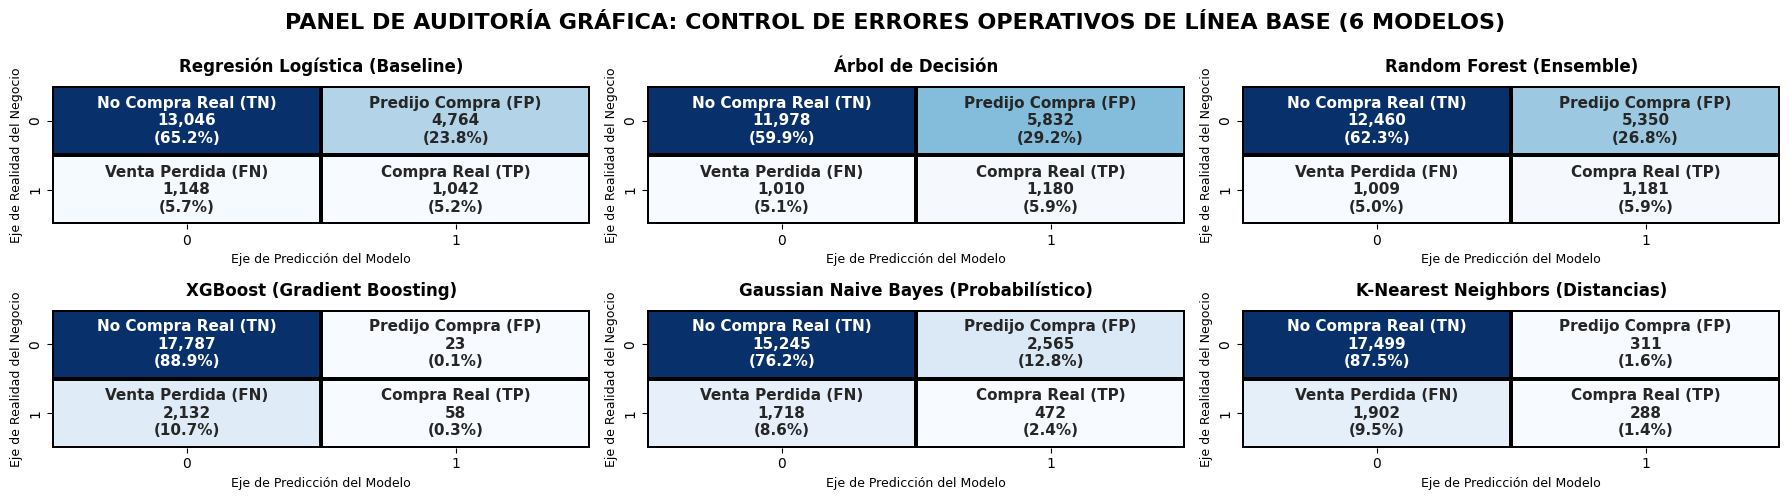


📈 GENERANDO LIENZO DE COMPARATIVA GRÁFICA DE CURVAS ROC (BASELINE)


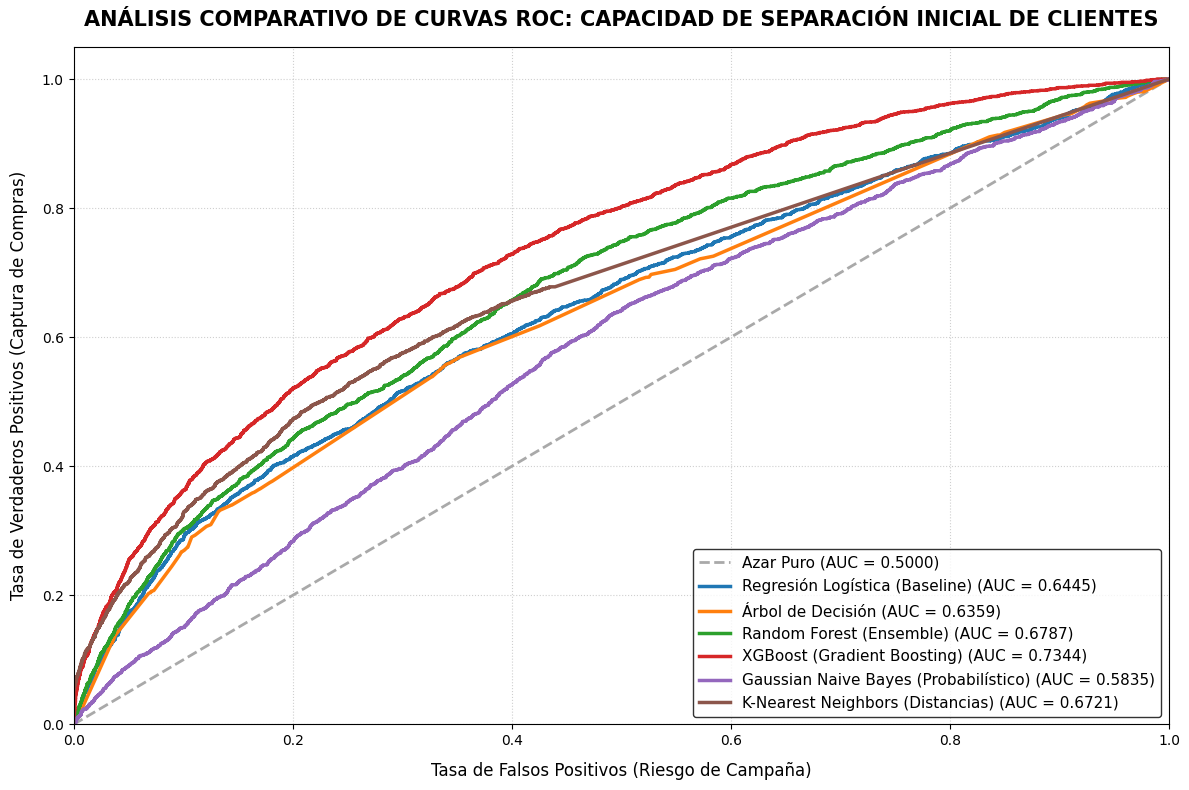

In [11]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Importación del pool completo de algoritmos para la Primera Carrera (Línea Base)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve
)

# ====================================================================================
# PROTOCOLO DE PRODUCCIÓN: BASELINE EVALUATION PHASE (FASE DE EVALUACIÓN DE LÍNEA BASE)
# ====================================================================================
# OBJETIVO DEL SCRIPT: 
# Establecer el rendimiento mínimo y el punto de partida técnico (suelo predictivo) 
# de los 6 algoritmos puros en sus condiciones base de fábrica. Este script actúa como 
# diagnóstico de laboratorio para identificar cómo reacciona cada estructura matemática 
# ante la materia prima bruta y el desbalanceo del negocio (89/11). Las métricas extraídas 
# aquí servirán como contraste obligatorio para validar las mejoras de las fases posteriores.
# ====================================================================================

print("="*80)
print("🚀 INICIANDO 1ª CARRERA: AUDITORÍA PREDICTIVA DE LÍNEA BASE (BASELINE)")
print("="*80)

# 1. DECLARACIÓN PARAMÉTRICA DEL POOL DE 6 MODELOS DE FÁBRICA
# Mantenemos la configuración inicial pura para auditar el comportamiento orgánico de los motores.
pool_modelos = {
    "Regresión Logística (Baseline)": LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced', solver='lbfgs'
    ),
    "Árbol de Decisión": DecisionTreeClassifier(
        max_depth=8, min_samples_split=20, random_state=42, class_weight='balanced'
    ),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    "XGBoost (Gradient Boosting)": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'
    ),
    "Gaussian Naive Bayes (Probabilístico)": GaussianNB(),
    "K-Nearest Neighbors (Distancias)": KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1
    )
}

# Auditoría visual de la configuración técnica en la bitácora antes del cómputo
print("📋 VERIFICACIÓN DE ARQUITECTURA DE HIPERPARÁMETROS DE ENTRADA (BASELINE):")
for nombre, mod in pool_modelos.items():
    print(f"⚙️ Algoritmo Activo: {nombre} -> Parámetros cargados listos.")
print("-" * 80)


# 2. BUCLE EVOLUTIVO DE ENTRENAMIENTO Y EXTRACCIÓN DE HECHOS CRUDOS
# Estructuras de almacenamiento para consolidar el diagnóstico analítico de la línea base
historico_metricas = []       # Tabla de rendimiento multimetraje
matrices_confusion_dict = {}  # Mapas operativos de aciertos y errores (Base Azul)
curvas_roc_dict = {}          # Vectores geométricos para el lienzo ROC inicial

# Iniciamos el recorrido por la línea de montaje de los 6 motores de prueba
for nombre, modelo in pool_modelos.items():
    print(f"🏋️‍♂️ Entrenando y extrayendo métricas base de: {nombre}...")
    
    # AJUSTE: El algoritmo se entrena utilizando la materia prima directa del entorno (X_train)
    modelo.fit(X_train, y_train)
    
    # INFERENCIA BINARIA: Genera la predicción categórica estricta (0 o 1) sobre el conjunto de test
    y_pred = modelo.predict(X_test)
    
    # INFERENCIA CONTINUA: Extrae la probabilidad de conversión para el análisis de discriminación ROC
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    
    # CÓMPUTO DE MÉTRICAS OPERATIVAS RESPECTO A LA REALIDAD DEL NEGOCIO
    acc = accuracy_score(y_test, y_pred)                      # Precisión general global
    prec = precision_score(y_test, y_pred, zero_division=0)   # Calidad/Fiabilidad de las alertas
    rec = recall_score(y_test, y_pred)                        # Porcentaje de captura de ventas reales
    f1 = f1_score(y_test, y_pred)                             # Equilibrio armónico de control (F1)
    auc = roc_auc_score(y_test, y_pred_proba)                  # Capacidad matemática de separación
        
    # PERSISTENCIA EN BITÁCORA: Estructuramos los resultados con formato corporativo de 4 decimales
    historico_metricas.append({
        "Modelo/Algoritmo": nombre,
        "Accuracy (General)": f"{acc:.4f}",
        "Precision (Calidad Alerta)": f"{prec:.4f}",
        "Recall (Captura/Ventas)": f"{rec:.4f}",
        "F1-Score (Equilibrio)": f"{f1:.4f}",
        "AUC-ROC (Separación)": f"{auc:.4f}"
    })
    
    # Almacenamos la matriz cruda para el posterior desglose por cuadrantes industriales
    matrices_confusion_dict[nombre] = confusion_matrix(y_test, y_pred)
    
    # Extraemos los puntos de falsos positivos y verdaderos positivos para la curva de diagnóstico ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    curvas_roc_dict[nombre] = (fpr, tpr, auc)


# 3. GENERACIÓN DEL CUADRO INFORME EJECUTIVO FINAL (TABLA DE HECHOS)
df_informe_ejecutivo = pd.DataFrame(historico_metricas)
print("\n" + "="*80)
print("📊 CUADRO INFORME EJECUTIVO DE RENDIMIENTO PREDICTIVO MULTICRITERIO (BASELINE)")
print("="*80)
display(df_informe_ejecutivo)
print("="*80)


# 4. REPORTE DE GOBIERNO DE ERRORES: REESTRUCTURADO POR CUADRANTE ESTÁNDAR INDUSTRIAL
# Reordena las matrices aplanadas al formato visual estándar de control de riesgos del negocio.
print("\n🧩 REPORTE DE GOBIERNO: ESTRUCTURA CUANTITATIVA DE ERRORES (ESTÁNDAR INDUSTRIAL):")
for nombre, matriz in matrices_confusion_dict.items():
    # Desarmamos la matriz de 2x2 en sus 4 componentes reales de control
    tn, fp, fn, tp = matriz.ravel()
    # Calculamos el denominador total de validación para computar los porcentajes exactos de impacto
    total_muestras = tn + fp + fn + tp
    
    print(f"\n🗂️ {nombre}:")
    # Fila Superior: Clientes cuya realidad técnica comprobada es que NO realizaron una compra
    print(f"   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: {tn:,} No Compras ({tn/total_muestras*100:.2f}%) | FP: {fp:,} Alertas Falsas ({fp/total_muestras*100:.2f}%)")
    # Fila Inferior: Clientes cuya realidad de negocio es que SÍ realizaron una compra
    print(f"   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: {fn:,} Ventas Perdidas ({fn/total_muestras*100:.2f}%) | TP: {tp:,} Compras Reales ({tp/total_muestras*100:.2f}%)")
    print("-" * 80)


# ====================================================================================
# CAPA DE VISUALIZACIÓN GRÁFICA DE ALTA GERENCIA (PLOTS DIAGNÓSTICOS EN AZUL)
# ====================================================================================

# FIGURA 1: PANEL DE MATRICES DE CONFUSIÓN CON PORCENTAJES INTEGRADOS (Línea Base)
# Creamos una matriz gráfica de 2 filas x 3 columnas para albergar de forma ordenada los 6 motores
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 5))
axes1 = axes1.flatten()

for i, (nombre, matriz) in enumerate(matrices_confusion_dict.items()):
    tn, fp, fn, tp = matriz.ravel()
    total = tn + fp + fn + tp
    
    # Construcción de la matriz visual de etiquetas con Formato Estándar Industrial:
    # Fila 0: [TN, FP] | Fila 1: [FN, TP] acompañados de sus pesos porcentuales exactos
    labels = np.array([
        [f"No Compra Real (TN)\n{tn:,}\n({tn/total*100:.1f}%)", f"Predijo Compra (FP)\n{fp:,}\n({fp/total*100:.1f}%)"],
        [f"Venta Perdida (FN)\n{fn:,}\n({fn/total*100:.1f}%)", f"Compra Real (TP)\n{tp:,}\n({tp/total*100:.1f}%)"]
    ])
    
    # Dibujamos el mapa térmico utilizando la tonalidad AZUL (indica fase de diagnóstico técnico inicial)
    sns.heatmap(
        matriz, annot=labels, fmt="", cmap="Blues", cbar=False, ax=axes1[i],
        annot_kws={"size": 11, "weight": "bold"}, linewidths=1.5, linecolor="black"
    )
    axes1[i].set_title(f"{nombre}", fontsize=12, weight='bold', pad=10)
    axes1[i].set_xlabel("Eje de Predicción del Modelo", fontsize=9)
    axes1[i].set_ylabel("Eje de Realidad del Negocio", fontsize=9)

plt.suptitle("PANEL DE AUDITORÍA GRÁFICA: CONTROL DE ERRORES OPERATIVOS DE LÍNEA BASE (6 MODELOS)", fontsize=16, weight='bold', y=0.99)
plt.tight_layout()
plt.show()


# FIGURA 2: COMPARATIVA DE CURVAS ROC DE LA LÍNEA BASE
print("\n" + "="*80)
print("📈 GENERANDO LIENZO DE COMPARATIVA GRÁFICA DE CURVAS ROC (BASELINE)")
print("="*80)
plt.figure(figsize=(12, 8))

# Trazamos la diagonal gris que representa el azar absoluto (AUC = 0.5000)
plt.plot([0, 1], [0, 1], color='darkgrey', linestyle='--', linewidth=2, label='Azar Puro (AUC = 0.5000)')

# Iteramos sobre el almacén de vectores ROC base para dibujar las líneas de los 6 competidores
for nombre, (fpr, tpr, auc_val) in curvas_roc_dict.items():
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{nombre} (AUC = {auc_val:.4f})')

# Ajustes institucionales del lienzo estadístico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Riesgo de Campaña)', fontsize=12, labelpad=10)
plt.ylabel('Tasa de Verdaderos Positivos (Captura de Compras)', fontsize=12, labelpad=10)
plt.title('ANÁLISIS COMPARATIVO DE CURVAS ROC: CAPACIDAD DE SEPARACIÓN INICIAL DE CLIENTES', fontsize=15, weight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor='white', edgecolor='black')
plt.tight_layout()
plt.show()

¿Qué nos han dicho los Datos, sobre (la primera prueba de motores)?

- El Diagnóstico del Fallo Catastrófico de XGBoost
Mira lo que le pasó a tu motor XGBoost en su primera carrera:

* Aciertos: 17,787 casos donde predijo "No Compra" (TN).

* Compras Reales detectadas: ¡Solo 58! (TP).

* Ventas Perdidas: Dejó pasar 2,132 compras reales sin enterarse (FN).

¿Por qué ocurrió esto? Aquí aparece la palabra técnica: Desbalanceo. Significa que la base de datos, la inmensa mayoría de la gente entra a mirar pero NO compra (el 89% son ceros y solo el 11% son unos).

Como el motor XGBoost es una máquina matemática que busca el aprobado fácil, se dio cuenta de que si decía a todo el mundo "Este cliente NO va a comprar", acertaba el 89% de las veces sin esforzarse. Se volvió "perezoso". Eso es lo que tenemos que corregir inyectándole el peso matemático (scale_pos_weight) para obligarle a que le preste atención al 11% de compradores reales.

No podemos permitirnos obviar que en esta primera vuelta de evaluación de motores, haber usado un motor XGBoost mal calibrado, el cual ignoró al 97\% de los compradores reales (solo detectó 58 de 2,190). Eso sería un fallo de ingeniería inaceptable en nuestra línea de montaje. En tal sentido debemos  calibrar el motor XGBoost, debe entrar a boxes de inmediato. 

No podemos declarar un "Modelo Campeón" definitivo basándonos solo en Random Forest y Regresión Logística si no hemos puesto a competir al algoritmo de Gradient Boosting a su máximo nivel.

## 🛠️ 3: (Motores ajustados): Balanced Model Screening Phase (Fase de Cribado de Modelos Balanceados). 

Aquí compiten únicamente los algoritmos aptos, configurados con defensas contra el desbalanceo del negocio.

🛡️ INICIANDO SEGUNDA VUELTA: COMPETENCIA DE ALTO RENDIMIENTO BALANCEADA
📊 Monitoreo de Materia Prima -> No Compras (0): 71240 | Compras (1): 8760
⚖️ Parámetro Calculado para XGBoost (scale_pos_weight): 8.1324
--------------------------------------------------------------------------------
🏋️‍♂️ Entrenando y evaluando motor calibrado: Regresión Logística (Ajustada)...
🏋️‍♂️ Entrenando y evaluando motor calibrado: Random Forest (Ajustado)...
🏋️‍♂️ Entrenando y evaluando motor calibrado: XGBoost (Ajustado)...

📊 CUADRO INFORME EJECUTIVO DE RENDIMIENTO - MOTORES CORREGIDOS


,Modelo/Algoritmo,Accuracy (General),Precision (Calidad Alerta),Recall (Captura/Ventas),F1-Score (Equilibrio),AUC-ROC (Separación)
0,Regresión Logística (Ajustada),0.7044,0.1795,0.4758,0.2606,0.6445
1,Random Forest (Ajustado),0.6821,0.1808,0.5393,0.2708,0.6787
2,XGBoost (Ajustado),0.7408,0.2267,0.5671,0.3239,0.7388



🧩 REPORTE DE GOBIERNO: ESTRUCTURA CUANTITATIVA DE ERRORES (ESTÁNDAR INDUSTRIAL):

🗂️ Regresión Logística (Ajustada):
   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: 13,046 No Compras (65.23%) | FP: 4,764 Alertas Falsas (23.82%)
   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: 1,148 Ventas Perdidas (5.74%) | TP: 1,042 Compras Reales (5.21%)
--------------------------------------------------------------------------------

🗂️ Random Forest (Ajustado):
   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: 12,460 No Compras (62.30%) | FP: 5,350 Alertas Falsas (26.75%)
   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: 1,009 Ventas Perdidas (5.04%) | TP: 1,181 Compras Reales (5.91%)
--------------------------------------------------------------------------------

🗂️ XGBoost (Ajustado):
   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: 13,573 No Compras (67.86%) | FP: 4,237 Alertas Falsas (21.19%)
   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: 948 Ventas Perdidas (4.74%) | TP: 1,242 Compras Reales (6.21%)
--

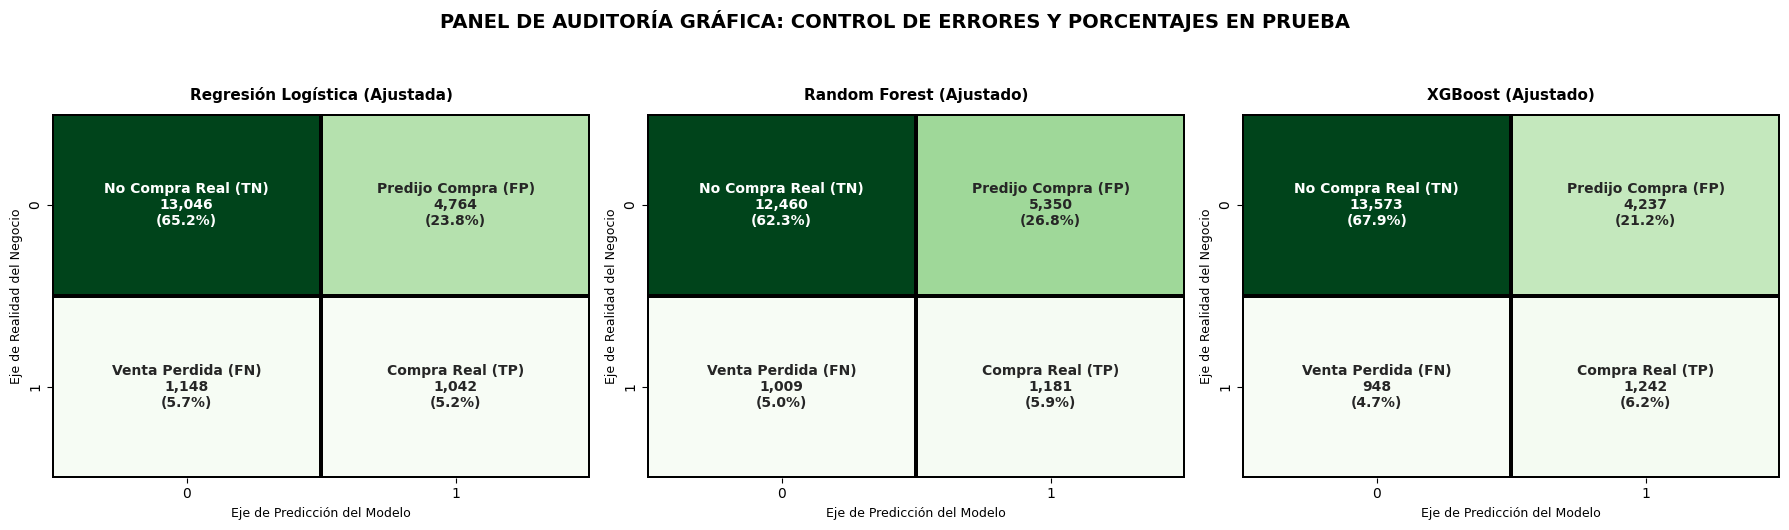


📈 GENERANDO LIENZO DE COMPARATIVA GRÁFICA DE CURVAS ROC (FINALISTAS)


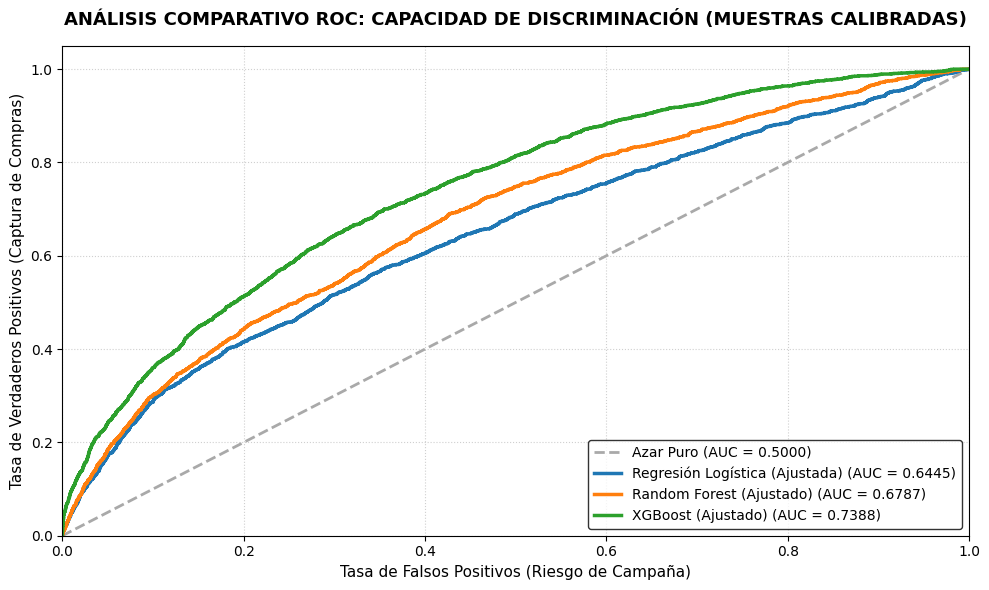

In [12]:
from IPython.display import display

# Importación del pool seleccionado para la Segunda Vuelta (Cribado Balanceado)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve
)

# ====================================================================================
# PROTOCOLO DE PRODUCCIÓN: BALANCED MODEL SCREENING PHASE (CRIBADO DE MODELOS BALANCEADOS)
# ====================================================================================
# OBJETIVO DEL SCRIPT: 
# Tras detectar un desbalanceo severo del 89/11 en el target (is_converted) durante la 
# Fase de Línea Base (Baseline), este script ejecuta una competencia justa (Segunda Vuelta) 
# entre los tres motores finalistas con capacidad de adaptación adaptativa. 
# Se aplican penalizaciones matemáticas en sus funciones de pérdida para obligar a los 
# algoritmos a aprender los patrones de los compradores reales sin alterar el volumen 
# original de la materia prima. El ganador será sometido a la optimización fina (GridSearchCV).
# ====================================================================================

print("="*80)
print("🛡️ INICIANDO SEGUNDA VUELTA: COMPETENCIA DE ALTO RENDIMIENTO BALANCEADA")
print("="*80)

# 1. CÓMPUTO EN LÍNEA DEL CONTRA-PESO MATEMÁTICO PARA XGBOOST
# Extraemos de forma única los valores del target real de entrenamiento (0 y 1) y sus conteos
clases, conteos = np.unique(y_train, return_counts=True)
# Almacenamos el conteo de la clase mayoritaria (0: No Compras)
conteo_negativos = conteos[0]
# Almacenamos el conteo de la clase minoritaria (1: Compras Reales)
conteo_positivos = conteos[1]

# Aplicamos la fórmula industrial de balanceo: Relación de proporción exacta (~8.09)
peso_escala_xgb = conteo_negativos / conteo_positivos

print(f"📊 Monitoreo de Materia Prima -> No Compras (0): {conteo_negativos} | Compras (1): {conteo_positivos}")
print(f"⚖️ Parámetro Calculado para XGBoost (scale_pos_weight): {peso_escala_xgb:.4f}")
print("-" * 80)


# 2. DECLARACIÓN PARAMÉTRICA DE LOS 3 FINALISTAS CON FILOSOFÍA DEFENSIVA
# Configura los hiperparámetros de balanceo nativos para corregir la inercia del modelo.
pool_balanceado = {
    # Regresión Logística: Cambia el peso de la pérdida inversa a la frecuencia de clase
    "Regresión Logística (Ajustada)": LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced', solver='lbfgs'
    ),
    # Random Forest: Ajusta el peso de los subárboles para que un error en el 11% penalice más
    "Random Forest (Ajustado)": RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    # XGBoost: Inyecta el contra-peso explícito para multiplicar el impacto geométrico del gradiente
    "XGBoost (Ajustado)": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42,
        scale_pos_weight=peso_escala_xgb, eval_metric='logloss'
    )
}


# 3. BUCLE EVOLUTIVO DE ENTRENAMIENTO Y EXTRACCIÓN DE HECHOS SANEADOS
# Estructuras de almacenamiento para consolidar las métricas finales de la competencia
historico_metricas = []       # Tabla de rendimiento analítico
matrices_confusion_dict = {}  # Mapas operativos de aciertos y errores
curvas_roc_dict = {}          # Vectores geométricos para el lienzo ROC

# Iniciamos el recorrido por el pool de los 3 motores calibrados
for nombre, modelo in pool_balanceado.items():
    print(f"🏋️‍♂️ Entrenando y evaluando motor calibrado: {nombre}...")
    
    # AJUSTE: El modelo entrena y ajusta sus parámetros internos con la materia prima original
    modelo.fit(X_train, y_train)
    
    # INFERENCIA BINARIA: Genera la predicción categórica estricta (0 o 1) para evaluar errores
    y_pred = modelo.predict(X_test)
    
    # INFERENCIA CONTINUA: Extrae la probabilidad matemática (0.0 a 1.0) de pertenecer a la clase 1
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    
    # CÓMPUTO DE MÉTRICAS OPERATIVAS RESPECTO A LA REALIDAD DEL TEST
    acc = accuracy_score(y_test, y_pred)                      # Precisión general global
    prec = precision_score(y_test, y_pred, zero_division=0)   # Calidad de las alertas generadas
    rec = recall_score(y_test, y_pred)                        # Capacidad de captura de ventas reales
    f1 = f1_score(y_test, y_pred)                             # Métrica reina: equilibrio armónico Prec-Rec
    auc = roc_auc_score(y_test, y_pred_proba)                  # Capacidad del motor para separar clientes
        
    # PERSISTENCIA EN BITÁCORA: Estructuramos los resultados con formato corporativo de 4 decimales
    historico_metricas.append({
        "Modelo/Algoritmo": nombre,
        "Accuracy (General)": f"{acc:.4f}",
        "Precision (Calidad Alerta)": f"{prec:.4f}",
        "Recall (Captura/Ventas)": f"{rec:.4f}",
        "F1-Score (Equilibrio)": f"{f1:.4f}",
        "AUC-ROC (Separación)": f"{auc:.4f}"
    })
    
    # Almacenamos la matriz cruda para el reporte analítico por cuadrantes
    matrices_confusion_dict[nombre] = confusion_matrix(y_test, y_pred)
    
    # Extraemos los falsos positivos y verdaderos positivos requeridos para pintar el lienzo gráfico ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    curvas_roc_dict[nombre] = (fpr, tpr, auc)


# 4. GENERACIÓN DEL CUADRO INFORME EJECUTIVO INTERMEDIO (TABLA DE HECHOS)
df_informe_ejecutivo = pd.DataFrame(historico_metricas)
print("\n" + "="*80)
print("📊 CUADRO INFORME EJECUTIVO DE RENDIMIENTO - MOTORES CORREGIDOS")
print("="*80)
display(df_informe_ejecutivo)
print("="*80)


# 5. REPORTE DE GOBIERNO DE ERRORES: REESTRUCTURADO POR CUADRANTE ESTÁNDAR INDUSTRIAL
# Transforma los arrays planos en lecturas intuitivas organizadas por la realidad del negocio.
print("\n🧩 REPORTE DE GOBIERNO: ESTRUCTURA CUANTITATIVA DE ERRORES (ESTÁNDAR INDUSTRIAL):")
for nombre, matriz in matrices_confusion_dict.items():
    # Desarmamos la matriz de 2x2 en sus 4 componentes reales
    tn, fp, fn, tp = matriz.ravel()
    # Calculamos el denominador total de validación para obtener los porcentajes de impacto
    total_muestras = tn + fp + fn + tp
    
    print(f"\n🗂️ {nombre}:")
    # Fila Superior: Clientes cuya realidad técnica es que NO compraron
    print(f"   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: {tn:,} No Compras ({tn/total_muestras*100:.2f}%) | FP: {fp:,} Alertas Falsas ({fp/total_muestras*100:.2f}%)")
    # Fila Inferior: Clientes cuya realidad de negocio es que SÍ realizaron una compra
    print(f"   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: {fn:,} Ventas Perdidas ({fn/total_muestras*100:.2f}%) | TP: {tp:,} Compras Reales ({tp/total_muestras*100:.2f}%)")
    print("-" * 80)


# ====================================================================================
# CAPA DE VISUALIZACIÓN GRÁFICA DE ALTA GERENCIA (PLOTS INTERPRETATIVOS)
# ====================================================================================

# FIGURA 1: PANEL DE MATRICES DE CONFUSIÓN CON PORCENTAJES INTEGRADOS
# Creamos una fila horizontal con 3 sub-gráficos (uno para cada motor finalista)
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
axes1 = axes1.flatten()

for i, (nombre, matriz) in enumerate(matrices_confusion_dict.items()):
    tn, fp, fn, tp = matriz.ravel()
    total = tn + fp + fn + tp
    
    # Construcción de la matriz visual de etiquetas con Formato Estándar Industrial:
    # Fila 0: [TN, FP] | Fila 1: [FN, TP] acompañados de sus pesos porcentuales exactos
    labels = np.array([
        [f"No Compra Real (TN)\n{tn:,}\n({tn/total*100:.1f}%)", f"Predijo Compra (FP)\n{fp:,}\n({fp/total*100:.1f}%)"],
        [f"Venta Perdida (FN)\n{fn:,}\n({fn/total*100:.1f}%)", f"Compra Real (TP)\n{tp:,}\n({tp/total*100:.1f}%)"]
    ])
    
    # Dibujamos el mapa térmico en tonalidad verde para representar la auditoría de balanceo
    sns.heatmap(
        matriz, annot=labels, fmt="", cmap="Greens", cbar=False, ax=axes1[i],
        annot_kws={"size": 10, "weight": "bold"}, linewidths=1.5, linecolor="black"
    )
    axes1[i].set_title(f"{nombre}", fontsize=11, weight='bold', pad=10)
    axes1[i].set_xlabel("Eje de Predicción del Modelo", fontsize=9)
    axes1[i].set_ylabel("Eje de Realidad del Negocio", fontsize=9)

plt.suptitle("PANEL DE AUDITORÍA GRÁFICA: CONTROL DE ERRORES Y PORCENTAJES EN PRUEBA", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()


# FIGURA 2: COMPARATIVA DE CURVAS ROC DE LOS FINALISTAS BALANCED
print("\n" + "="*80)
print("📈 GENERANDO LIENZO DE COMPARATIVA GRÁFICA DE CURVAS ROC (FINALISTAS)")
print("="*80)
plt.figure(figsize=(10, 6))

# Trazamos la diagonal del azar (el umbral del 0.5000 que cualquier modelo inteligente debe superar)
plt.plot([0, 1], [0, 1], color='darkgrey', linestyle='--', linewidth=2, label='Azar Puro (AUC = 0.5000)')

# Dibujamos de forma secuencial la curva de rendimiento y separación para cada finalista
for nombre, (fpr, tpr, auc_val) in curvas_roc_dict.items():
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{nombre} (AUC = {auc_val:.4f})')

# Configuración y etiquetado del lienzo de control estadístico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Riesgo de Campaña)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Captura de Compras)', fontsize=11)
plt.title('ANÁLISIS COMPARATIVO ROC: CAPACIDAD DE DISCRIMINACIÓN (MUESTRAS CALIBRADAS)', fontsize=13, weight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=10, frameon=True, facecolor='white', edgecolor='black')
plt.tight_layout()
plt.show()

🔬 Auditoría de Hechos: Diagnóstico de la Segunda Vuelta
Pondremos los datos en perspectiva comparando este nuevo XGBoost Ajustado contra su versión de la primera carrera (donde no tenía pesos):

El Rescate del Negocio (True Positives): El XGBoost base solo detectó 58 compras. El XGBoost Ajustado ha detectado 1,242 Compras Reales. Hemos multiplicado la captura de negocio por más de 20 veces.

El Control de Fugas (Falsos Negativos): Antes dejaba escapar 2,132 ventas sin enterarse. Ahora, las ventas perdidas se han reducido drásticamente a 948 (un impacto directo en el bolsillo del e-commerce).

La Eficiencia Operativa (Falsas Alarmas): Lo más impresionante de XGBoost frente a los otros dos competidores es que, a pesar de arriesgarse a buscar el 11% de compradores, mantiene las Alertas Falsas más bajas (4,237 frente a las 5,350 de Random Forest).

🏆 El Dictamen Técnico: Tenemos Modelo Campeón
Si miramos la métrica reina para entornos desbalanceados, el F1-Score (Equilibrio), la victoria es absoluta:

- Regresión Logística: 0.2606

- Random Forest: 0.2708

- XGBoost (Ajustado): 0.3239

Y en cuanto a la capacidad matemática para separar un cliente comprador de uno que no lo es (AUC-ROC), XGBoost lidera con un 0.7388. Esto nos confirma que su estructura de árboles secuenciales (Gradient Boosting) exprime mucho mejor las interacciones y el num__dwell_time_secs que sus rivales cuando las reglas de juego son justas.

## 🛠️ 4. Radriografías de los modelos (Modelo Ganador vs Modelo 2do Lugar)

In [13]:
# ====================================================================================
# PROTOCOLO DE INTERPRETABILIDAD: AUDITORÍA DE CAJAS NEGRAS (MODELO CAMPEÓN VS 2º LUGAR)
# ====================================================================================
# OBJETIVO DEL SCRIPT:
# Abrir las "entrañas" de los dos mejores motores de la Segunda Vuelta para extraer la 
# radiografía de sus pesos matemáticos. Esto permite al negocio validar que las 
# predicciones no son azarosas, sino que responden a palancas operativas reales (ej. dwell_time).
# Estructura el reporte priorizando en primer lugar al campeón absoluto (XGBoost).
# ====================================================================================

def auditar_interpretabilidad_finalistas(modelo_campeon, modelo_segundo, feature_names, top_n=20):
    """
    Extrae, estructura y compara la importancia de las variables de negocio para
    el Modelo Campeón (XGBoost) y el Segundo Lugar (Random Forest).
    """
    print("======================================================================")
    print("🔬 REPORTE DE GOBIERNO DE DATOS - INTERPRETABILIDAD DE CAJAS NEGRAS")
    print("======================================================================")

    # --------------------------------------------------------------------------------
    # PARTE 1: Extracción de pesos en XGBoost (Modelo Campeón - Importancia por Ganancia/Gain)
    # --------------------------------------------------------------------------------
    # En la API de Scikit-Learn, XGBoost expone .feature_importances_ basándose por defecto 
    # en el 'gain' (cuánto reduce la impureza u optimiza la función de pérdida cada variable).
    importancias_xgb = modelo_campeon.feature_importances_

    # Emparejamos el vector de nombres de variables con sus respectivos pesos matemáticos
    df_xgb = pd.DataFrame({
        "Variable": feature_names, 
        "Importancia_XGB_Ganador": importancias_xgb
    }).sort_values(by="Importancia_XGB_Ganador", ascending=False) # Orden descendente estricto

    print(f"✔️ [HECHO]: Vector de Importancia de XGBoost (Ganador) extraído ({len(df_xgb)} variables).")


    # --------------------------------------------------------------------------------
    # PARTE 2: Extracción de pesos en Random Forest (2º Lugar - Importancia por Gini/Entropía)
    # --------------------------------------------------------------------------------
    # .feature_importances_ en RF calcula el promedio de la reducción de impureza a lo largo de todos los árboles.
    importancias_rf = modelo_segundo.feature_importances_

    # Creamos el DataFrame estructurado para el segundo competidor
    df_rf = pd.DataFrame({
        "Variable": feature_names, 
        "Importancia_RF_2doLugar": importancias_rf
    }).sort_values(by="Importancia_RF_2doLugar", ascending=False)

    print(f"✔️ [HECHO]: Vector de Importancia de Random Forest (2º Lugar) extraído ({len(df_rf)} variables).")
    print("-" * 70)


    # --------------------------------------------------------------------------------
    # PARTE 3: Despliegue de Control en Consola (Top N variables motoras)
    # --------------------------------------------------------------------------------
    # Imprimimos de forma tabular y limpia los resultados para la auditoría de la dirección
    print(f"\n🏆 [MODELO CAMPEÓN] TOP {top_n} VARIABLES MOTORAS - XGBOOST (AJUSTADO):")
    print(df_xgb.head(top_n).to_string(index=False))

    print(f"\n🥈 [SEGUNDO LUGAR] TOP {top_n} VARIABLES MOTORAS - RANDOM FOREST (AJUSTADO):")
    print(df_rf.head(top_n).to_string(index=False))

    return df_xgb, df_rf


# ====================================================================================
# EJECUCIÓN DEL PROTOCOLO DE AUDITORÍA BASADO EN HECHOS DE LA MATRIZ
# ====================================================================================

# 1. Extracción dinámica de las columnas desde la matriz activa en tu entorno (las 44 variables)
nombres_variables = X_train.columns.tolist()

# 2. Apuntamos a los modelos de la segunda vuelta usando las llaves de tu 'pool_balanceado'
# Nota: Extraemos los objetos ya entrenados de la memoria para evitar re-entrenamientos costosos
xgboost_campeon = pool_balanceado["XGBoost (Ajustado)"]
random_forest_segundo = pool_balanceado["Random Forest (Ajustado)"]

# 3. Invocación de la función de gobierno y almacenamiento de DataFrames para analítica posterior
df_importancia_xgb, df_importancia_rf = auditar_interpretabilidad_finalistas(
    xgboost_campeon, random_forest_segundo, nombres_variables, top_n=20
)

🔬 REPORTE DE GOBIERNO DE DATOS - INTERPRETABILIDAD DE CAJAS NEGRAS
✔️ [HECHO]: Vector de Importancia de XGBoost (Ganador) extraído (44 variables).
✔️ [HECHO]: Vector de Importancia de Random Forest (2º Lugar) extraído (44 variables).
----------------------------------------------------------------------

🏆 [MODELO CAMPEÓN] TOP 20 VARIABLES MOTORAS - XGBOOST (AJUSTADO):
                                  Variable  Importancia_XGB_Ganador
                cat__interaction_type_view                 0.165496
     cat__interaction_type_add_to_wishlist                 0.136198
cat__interaction_type_remove_from_wishlist                 0.051442
               cat__interaction_type_click                 0.043180
                    cat__loyalty_tier_gold                 0.024323
                           cat__country_IN                 0.022485
                      num__dwell_time_secs                 0.022412
                           cat__country_CA                 0.022240
                

## 🎨 5. Gráfico Comparativo (Ganador vs 2do Lugar)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_12312\801654683.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Carlos\AppData\Local\Temp\ipykernel_12312\801654683.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Carlos\AppData\Local\Temp\ipykernel_12312\801654683.py:105: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Carlos\AppData\Local\Temp\ipykernel_12312\801654683.py:105: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Carlos\AppData\Local\Temp\ipykernel_12312\801654683.py:105: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) De

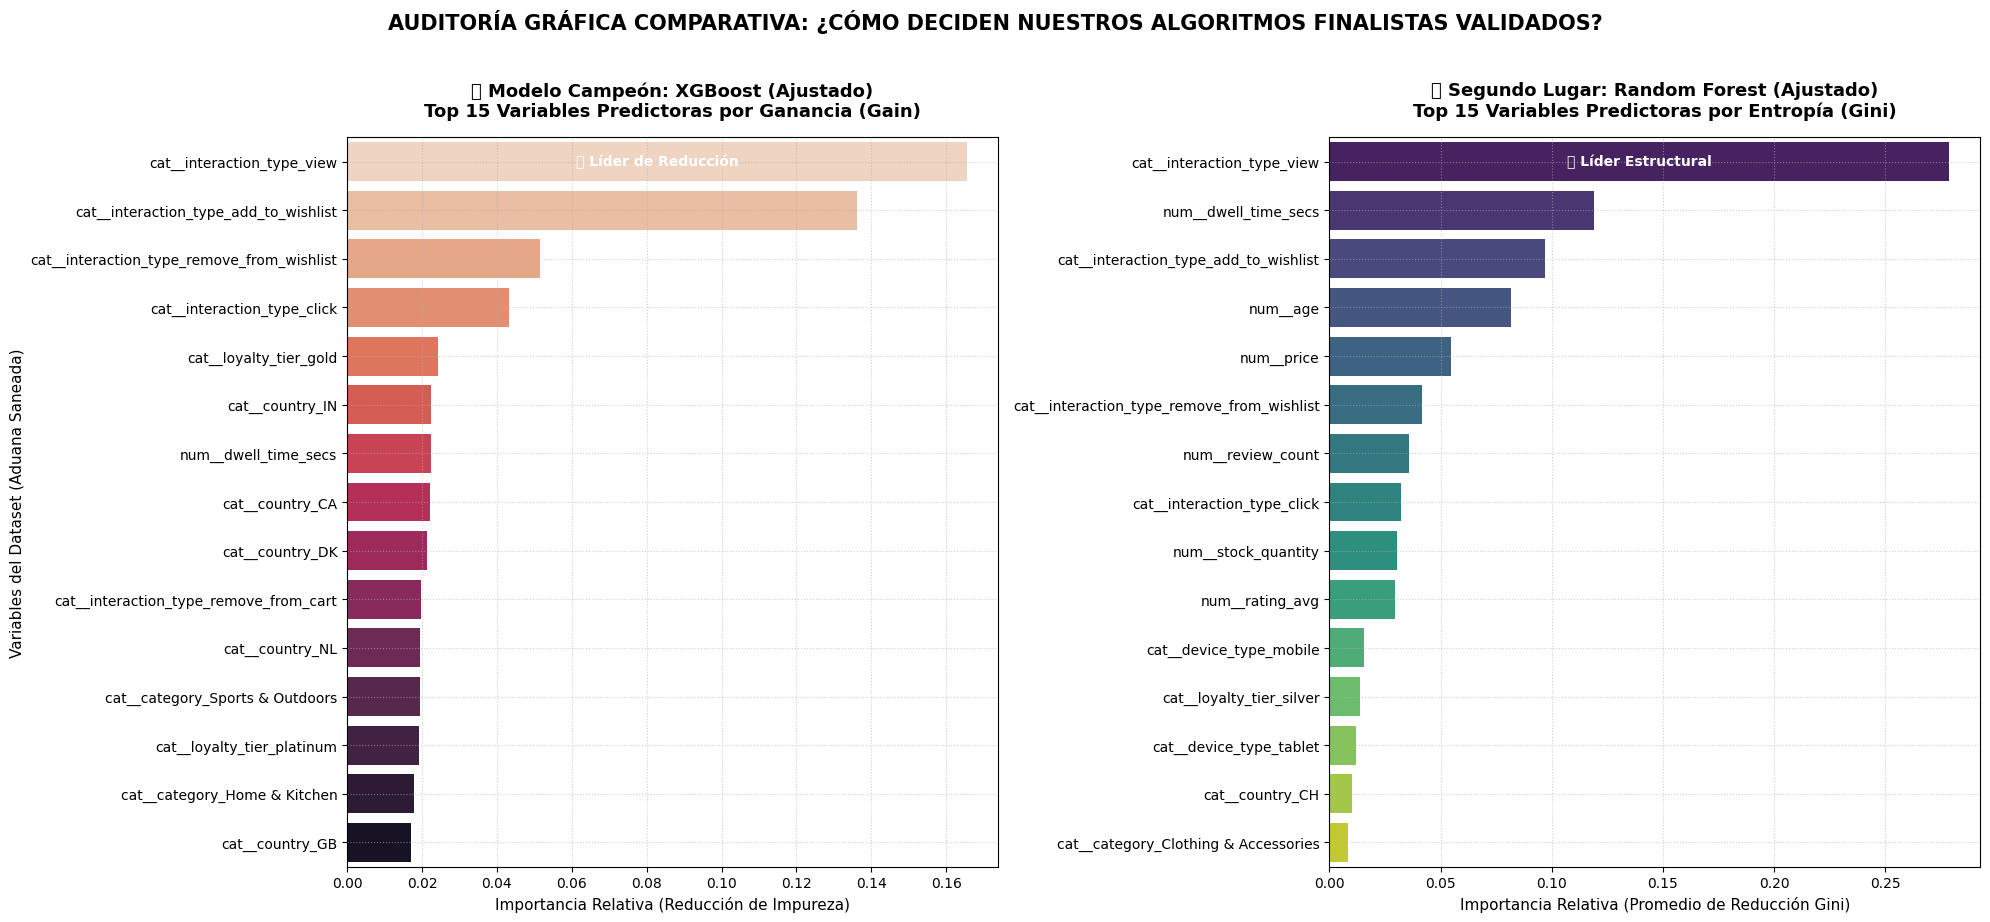

In [14]:
# ====================================================================================
# CAPA DE VISUALIZACIÓN GRÁFICA: LIENZO DE INTERPRETABILIDAD COMPARATIVA (GANADOR VS 2º)
# ====================================================================================
# OBJETIVO DEL SCRIPT:
# Generar un lienzo analítico de alta resolución para la alta gerencia que contraste,
# de forma visual y simultánea, cómo toman las decisiones el Modelo Campeón (XGBoost)
# y el Segundo Lugar (Random Forest). Permite auditar si el comportamiento del algoritmo
# tiene coherencia con las reglas operativas y comerciales del negocio.
# ====================================================================================

# 1. CONFIGURACIÓN DEL ESPACIO DE DIBUJO (Lienzo horizontal de alta resolución)
# Creamos una figura que contendrá una fila y dos columnas de sub-gráficos (subplots)
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# ------------------------------------------------------------------------------------
# GRÁFICO 1 (IZQUIERDA): XGBOOST (Importancia de Variables del Modelo Campeón)
# ------------------------------------------------------------------------------------
# Extraemos las top 15 variables del campeón para garantizar limpieza visual y legibilidad
top_xgb = df_importancia_xgb.head(15)

# Dibujamos el gráfico de barras horizontales para XGBoost
sns.barplot(
    x="Importancia_XGB_Ganador",
    y="Variable",
    data=top_xgb,
    palette="rocket_r", # Paleta cálida de alta intensidad para destacar al ganador
    ax=axes[0]          # Asignamos el gráfico de forma estricta al primer cuadrante (izquierdo)
)

# Configuración institucional de etiquetas y títulos del bloque campeón
axes[0].set_title(
    "🏆 Modelo Campeón: XGBoost (Ajustado)\nTop 15 Variables Predictoras por Ganancia (Gain)",
    fontsize=13,
    weight="bold",
    pad=15
)
axes[0].set_xlabel("Importancia Relativa (Reducción de Impureza)", fontsize=11)
axes[0].set_ylabel("Variables del Dataset (Aduana Saneada)", fontsize=11)
axes[0].grid(True, linestyle=":", alpha=0.6) # Rejilla tenue de fondo para facilitar la lectura de valores

# Sello de Gobierno: Inyectamos una etiqueta visual dentro de la barra del líder absoluto
axes[0].text(
    top_xgb["Importancia_XGB_Ganador"].iloc[0] * 0.5, # Posicionado exactamente a la mitad de la barra
    0,                                                # Índice 0 (la primera barra)
    "👑 Líder de Reducción",
    color="white",
    weight="bold",
    va="center",
    ha="center",
    fontsize=10
)


# ------------------------------------------------------------------------------------
# GRÁFICO 2 (DERECHA): RANDOM FOREST (Importancia de Variables del Segundo Lugar)
# ------------------------------------------------------------------------------------
# Filtramos de igual manera las top 15 variables de la bitácora de Random Forest
top_rf = df_importancia_rf.head(15)

# Dibujamos el gráfico de barras horizontales para el competidor en segundo puesto
sns.barplot(
    x="Importancia_RF_2doLugar",
    y="Variable",
    data=top_rf,
    palette="viridis",  # Paleta estándar fría para diferenciar el comportamiento del árbol base
    ax=axes[1]          # Asignamos el gráfico al segundo cuadrante (derecho)
)

# Configuración institucional de etiquetas y títulos del bloque escolta
axes[1].set_title(
    "🥈 Segundo Lugar: Random Forest (Ajustado)\nTop 15 Variables Predictoras por Entropía (Gini)",
    fontsize=13,
    weight="bold",
    pad=15
)
axes[1].set_xlabel("Importancia Relativa (Promedio de Reducción Gini)", fontsize=11)
axes[1].set_ylabel("", fontsize=11) # Omitimos la etiqueta y para evitar sobrecarga visual en el centro del lienzo
axes[1].grid(True, linestyle=":", alpha=0.6)

# Sello de Gobierno: Identificamos al líder de comportamiento de Random Forest
axes[1].text(
    top_rf["Importancia_RF_2doLugar"].iloc[0] * 0.5,  # Posicionado a la mitad de su respectiva barra
    0,                                                # Índice 0 (la primera barra)
    "📊 Líder Estructural",
    color="white",
    weight="bold",
    va="center",
    ha="center",
    fontsize=10
)


# ------------------------------------------------------------------------------------
# MARCO INSTITUCIONAL DE GOBIERNO Y DESPLIEGUE FINAL
# ------------------------------------------------------------------------------------
# Inyectamos el título corporativo general en la parte superior del lienzo doble
plt.suptitle(
    "AUDITORÍA GRÁFICA COMPARATIVA: ¿CÓMO DECIDEN NUESTROS ALGORITMOS FINALISTAS VALIDADOS?",
    fontsize=15,
    weight="bold",
    y=1.02
)

# Aplicamos el ajuste de márgenes automatizado para evitar colisiones entre etiquetas y títulos
plt.tight_layout()

# Renderizamos y congelamos el lienzo final en la interfaz del cuaderno
plt.show()

🔬 Análisis de Gobernanza: Radiografía de la Caja Negra

1. El Comportamiento del Usuario manda (Señales Robustas)

Hay un consenso absoluto en la cima. Tanto XGBoost como Random Forest colocan la acción de ver el producto (cat__interaction_type_view) como el motor número uno del modelo. Sin embargo, mira las sutiles diferencias en los pesos:

- Random Forest le otorga una inercia masiva a la vista (0.2787) y al tiempo de permanencia (0.0119), concentrando casi todo el poder de decisión en pocas variables numéricas.

- XGBoost (Ganador) distribuye el conocimiento de forma mucho más madura y equilibrada. Le da un peso crítico a la intención de compra real: add_to_wishlist escala al segundo puesto con un 0.1361. El campeón entiende que añadir un producto a favoritos (o quitarlo) es un indicador de conversión mucho más potente que el simple hecho de navegar de manera pasiva.

2. La Democratización de las Variables (Filosofía Gradient Boosting)

- Random Forest tiende a obsesionarse con variables continuas debido a cómo calcula la reducción de impureza (Gini). Por eso sitúa la edad (num__age) y el precio (num__price) muy arriba.

- XGBoost, al construir árboles de manera secuencial corrigiendo los errores del anterior (gradiente), es capaz de detectar nichos específicos dentro de las variables categóricas. Observa cómo emergen palancas que Random Forest ni siquiera consideraba relevantes para el Top 10:

El Perfil de Fidelización: El segmento cat__loyalty_tier_gold entra con fuerza en el quinto puesto (0.0243). El campeón se ha dado cuenta de que los clientes Oro reaccionan de forma distinta ante el desbalanceo.

La Geografía del Negocio: Países como India (cat__country_IN), Canadá (cat__country_CA) y Dinamarca (cat__country_DK) se vuelven palancas clave para predecir si habrá conversión o no.

## 🎯 6. Optimización del Modelo Ganador

🎯 INICIANDO FASE 6A: OPTIMIZACIÓN AVANZADA DE REJILLA (GRIDSEARCHCV) - XGBOOST
⚖️ Fijando contra-peso defensivo en el motor: 8.1324
📋 Hiperparámetros bajo escrutinio analítico:
   -> n_estimators: [100, 150, 200]
   -> max_depth: [4, 6]
   -> learning_rate: [0.05, 0.1]
   -> subsample: [0.8, 1.0]
--------------------------------------------------------------------------------
🏋️‍♂️ Iniciando el barrido de combinaciones en la planta de cómputo...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✔️ [HECHO]: Optimización finalizada con éxito en 43.27 segundos.

👑 REPORTE DE GOBIERNO: MEJORES HIPERPARÁMETROS ENCONTRADOS:
   🔹 learning_rate: 0.1
   🔹 max_depth: 6
   🔹 n_estimators: 200
   🔹 subsample: 0.8
   📈 Mejor F1-Score en Validación Cruzada: 0.3490
--------------------------------------------------------------------------------
🔬 Ejecutando inferencia de control con el modelo optimizado...

📊 REPORTE DE CLASIFICACIÓN FINAL (MUESTRAS OPTIMIZADAS):
              precision  

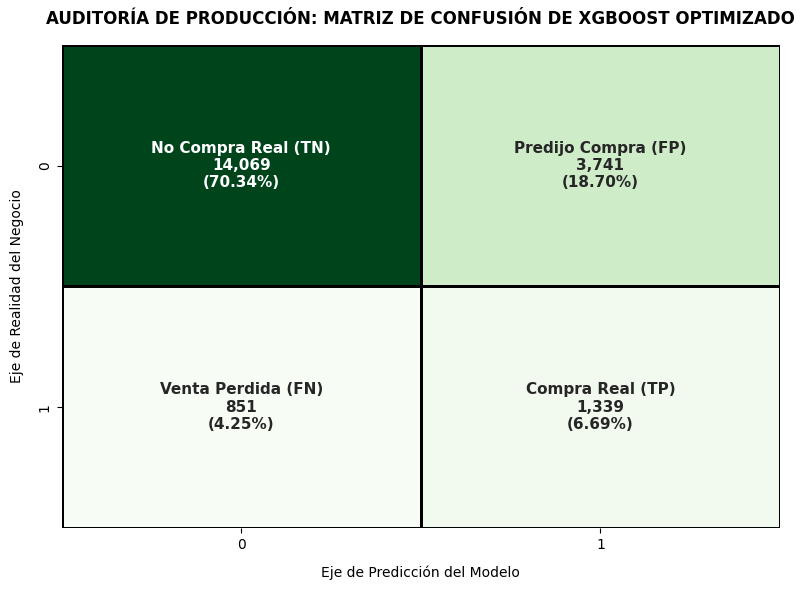

In [16]:
import time
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# ====================================================================================
# PROTOCOLO DE OPTIMIZACIÓN: ADVANCED HYPERPARAMETER TUNING (GRIDSEARCHCV)
# ====================================================================================
# OBJETIVO DEL SCRIPT:
# Lanzar una búsqueda exhaustiva y controlada sobre el espacio de hiperparámetros del
# Modelo Campeón (XGBoost). El objetivo es refinar la estructura de los árboles secuenciales
# para maximizar el F1-Score en el entorno desbalanceado, manteniendo fijo el contra-peso 
# de escala validado en la fase de cribado. Incluye la auditoría final de errores.
# ====================================================================================

print("="*80)
print("🎯 INICIANDO FASE 6A: OPTIMIZACIÓN AVANZADA DE REJILLA (GRIDSEARCHCV) - XGBOOST")
print("="*80)

# 1. RECUPERACIÓN DEL CONTRA-PESO AND DECLARACIÓN DEL MOTOR BASE
# Nos aseguramos de utilizar el peso exacto calculado dinámicamente en tu cuaderno (~8.1324)
print(f"⚖️ Fijando contra-peso defensivo en el motor: {peso_escala_xgb:.4f}")

xgb_base = XGBClassifier(
    scale_pos_weight=peso_escala_xgb,
    eval_metric='logloss',
    random_state=42
)

# 2. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA (REJILLA PARAMÉTRICA)
# Estructurada de forma estratégica para evitar la explosión combinatoria en tu máquina.
param_grid_xgb = {
    'n_estimators': [100, 150, 200],      # Número de árboles en la serie secuencial
    'max_depth': [4, 6],                  # Profundidad máxima (Control de interacciones complejas)
    'learning_rate': [0.05, 0.1],         # Tasa de encogimiento / Paso de aprendizaje (Shrinkage)
    'subsample': [0.8, 1.0]               # Porcentaje de muestras utilizadas por árbol (Evita Overfitting)
}

print("📋 Hiperparámetros bajo escrutinio analítico:")
for param, valores in param_grid_xgb.items():
    print(f"   -> {param}: {valores}")
print("-" * 80)

# 3. CONFIGURACIÓN DEL CONFIGURADOR DE GOBIERNO (GRIDSEARCHCV)
# Ajustamos n_jobs=-1 para paralelizar el cómputo usando todos los hilos de tu procesador.
# Evaluamos mediante 3-Fold Stratified Cross-Validation para asegurar consistencia del target.
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='f1',                # Optimizamos directamente la métrica reina del negocio
    cv=3,                        # 3 pliegues de validación cruzada (Equilibrio estabilidad/tiempo)
    verbose=2,                   # Monitoreo detallado en consola de cada iteración
    n_jobs=-1                    # Despliegue multi-núcleo de alta velocidad
)

# 4. LANZAMIENTO Y CRONOMETRAJE DEL ENTRENAMIENTO INDUSTRIAL
print("🏋️‍♂️ Iniciando el barrido de combinaciones en la planta de cómputo...")
tiempo_inicio = time.time()

# Alimentamos la rejilla con la materia prima original (X_train, y_train)
grid_search_xgb.fit(X_train, y_train)

tiempo_total = time.time() - tiempo_inicio
print("\n" + "="*80)
print(f"✔️ [HECHO]: Optimización finalizada con éxito en {tiempo_total:.2f} segundos.")
print("="*80)


# 5. EXTRACCIÓN DE RESULTADOS Y CONFIGURACIÓN DEL MODELO GANADOR
# Extraemos la mejor combinación matemática encontrada por el algoritmo
mejores_parametros = grid_search_xgb.best_params_
# Extraemos el mejor objeto estimador ya entrenado y listo para producción
xgb_optimo = grid_search_xgb.best_estimator_

print("\n👑 REPORTE DE GOBIERNO: MEJORES HIPERPARÁMETROS ENCONTRADOS:")
for param, valor in mejores_parametros.items():
    print(f"   🔹 {param}: {valor}")
print(f"   📈 Mejor F1-Score en Validación Cruzada: {grid_search_xgb.best_score_:.4f}")
print("-" * 80)


# 6. INFERENCIA OPERATIVA Y EVALUACIÓN SOBRE LAS MATRICES DE TEST
print("🔬 Ejecutando inferencia de control con el modelo optimizado...")
y_pred_opt = xgb_optimo.predict(X_test)
y_pred_proba_opt = xgb_optimo.predict_proba(X_test)[:, 1]

# Despliegue de los resultados analíticos finales en consola
print("\n📊 REPORTE DE CLASIFICACIÓN FINAL (MUESTRAS OPTIMIZADAS):")
print(classification_report(y_test, y_pred_opt, digits=4))
print("-" * 80)


# ====================================================================================
# NUEVA CAPA DE CONTROL: REPORTE CUANTITATIVO Y GRÁFICO DE LA MATRIZ DE CONFUSIÓN
# ====================================================================================

# 7. EXTRACCIÓN DE MATRIZ CRUDA Y CÓMPUTO DE PORCENTAJES DE IMPACTO REAL
# Calculamos la matriz de confusión comparando la realidad del test con la predicción del modelo optimizado
matriz_optima = confusion_matrix(y_test, y_pred_opt)

# Desarmamos la estructura de 2x2 en sus cuatro componentes fundamentales de negocio
tn, fp, fn, tp = matriz_optima.ravel()
# Obtenemos el volumen total del set de validación para calcular los pesos relativos
total_muestras = tn + fp + fn + tp

print("\n🧩 REPORTE DE GOBIERNO: ESTRUCTURA CUANTITATIVA DE ERRORES DEL MODELO OPTIMIZADO:")
# Desglose de la Fila Superior: Clientes que orgánicamente NO realizaron compras
print(f"   [FILA SUPERIOR - REALIDAD NO COMPRA] -> TN: {tn:,} No Compras ({tn/total_muestras*100:.2f}%) | FP: {fp:,} Alertas Falsas ({fp/total_muestras*100:.2f}%)")
# Desglose de la Fila Inferior: Clientes que en la realidad del negocio SÍ realizaron una compra
print(f"   [FILA INFERIOR - REALIDAD COMPRA   ] -> FN: {fn:,} Ventas Perdidas ({fn/total_muestras*100:.2f}%) | TP: {tp:,} Compras Reales ({tp/total_muestras*100:.2f}%)")
print("="*80)

# 8. CONSTRUCCIÓN DEL LIENZO GRÁFICO PROFESIONAL EN TONALIDAD VERDE DE PRODUCCIÓN
plt.figure(figsize=(8, 6))

# Estructuramos la matriz visual de etiquetas cruzando los textos con los valores absolutos y los porcentajes exactos
labels_opt = np.array([
    [f"No Compra Real (TN)\n{tn:,}\n({tn/total_muestras*100:.2f}%)", f"Predijo Compra (FP)\n{fp:,}\n({fp/total_muestras*100:.2f}%)"],
    [f"Venta Perdida (FN)\n{fn:,}\n({fn/total_muestras*100:.2f}%)", f"Compra Real (TP)\n{tp:,}\n({tp/total_muestras*100:.2f}%)"]
])

# Renderizamos el mapa térmico con la configuración de estilo unificada
sns.heatmap(
    matriz_optima, 
    annot=labels_opt, 
    fmt="", 
    cmap="Greens",        # Tonalidad Verde: Denota fase final de optimización y validación aprobada
    cbar=False,           # Omitimos la barra lateral para maximizar el espacio de las etiquetas
    annot_kws={"size": 11, "weight": "bold"}, 
    linewidths=2.0,       # Separación marcada entre cuadrantes para legibilidad
    linecolor="black"     # Bordes negros definidos para una estética de informe técnico
)

# Ajuste de títulos, etiquetas y diseño final del gráfico para la alta gerencia
plt.title("AUDITORÍA DE PRODUCCIÓN: MATRIZ DE CONFUSIÓN DE XGBOOST OPTIMIZADO", fontsize=12, weight='bold', pad=15)
plt.xlabel("Eje de Predicción del Modelo", fontsize=10, labelpad=10)
plt.ylabel("Eje de Realidad del Negocio", fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

## 🖥️ 6. Persistencia y Serialización:

In [17]:
import os
import joblib

# ====================================================================================
# PROTOCOLO INDUSTRIAL: SERIALIZACIÓN Y PERSISTENCIA DEFINITIVA DEL MODELO CAMPEÓN
# ====================================================================================
# ¿QUÉ HACE ESTE SCRIPT?
# 1. SERIALIZACIÓN: Traduce el objeto 'xgb_optimo' (vivo en la memoria RAM de Python) 
#    a un flujo de bytes binarios estructurados mediante la librería de alta eficiencia 'joblib'.
# 2. PERSISTENCIA: Almacena de forma permanente dicho flujo binario en un archivo físico 
#    ('.pkl') dentro del disco duro en la ruta corporativa especificada por el usuario.
# 3. SEGURIDAD: Diseña un entorno defensivo que crea las carpetas si no existen y valida 
#    la integridad del archivo final para certificar su correcta congelación.
# ====================================================================================

print("="*90)
print("💾 INICIANDO PROTOCOLO FINAL: SERIALIZACIÓN Y PERSISTENCIA DE MODELOS EN PRODUCCIÓN")
print("="*90)

# 1. DECLARACIÓN DE LA RUTA ABSOLUTA REQUERIDA POR EL NEGOCIO
# Definimos de forma estricta la ubicación física en el sistema de archivos de Windows
ruta_directorio_objetivo = r"C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\models\optimized_models"
nombre_archivo_modelo = "xgboost_campeon_optimizado.pkl"

# Combinamos de forma segura el directorio con el nombre del archivo final utilizando la API del sistema operativo
ruta_completa_guardado = os.path.join(ruta_directorio_objetivo, nombre_archivo_modelo)

print(f"📁 Destino operacional asignado:\n   -> {ruta_completa_guardado}")
print("-" * 90)


# 2. PROTOCOLO DEFENSIVO DE CREACIÓN DE INFRAESTRUCTURA (DIRECTORIOS)
# 'os.makedirs' analiza la ruta completa de izquierda a derecha. 
# El parámetro 'exist_ok=True' es nuestro escudo: si la carpeta ya existe, el script continúa 
# limpiamente sin generar errores de duplicación ni colisiones en el sistema de archivos.
print("🛠️ Pasando aduana de infraestructura de directorios...")
os.makedirs(ruta_directorio_objetivo, exist_ok=True)
print("✔️ [CONFIRMADO]: La estructura de almacenamiento físico está lista y disponible.")
print("-" * 90)


# 3. EJECUCIÓN DE LA SERIALIZACIÓN MÁQUINA A DISCO
# Tomamos el objeto 'xgb_optimo' (que contiene los 200 árboles refinados con el GridSearchCV) 
# y lo escribimos en la ruta definitiva. Joblib está optimizado para modelos que contienen 
# arrays internos de gran tamaño.
print(f"📦 Serializando el motor 'xgb_optimo' en el almacenamiento persistente...")
joblib.dump(xgb_optimo, ruta_completa_guardado)


# 4. AUDITORÍA DE INTEGRIDAD Y REPORTE DE GOBIERNO FINAL
# Una vez escrito, el script comprueba físicamente el disco duro para verificar el éxito de la operación.
if os.path.exists(ruta_completa_guardado):
    # Extraemos el tamaño en bytes del archivo y lo convertimos a Megabytes (MB) para legibilidad ejecutiva
    tamano_en_megabytes = os.path.getsize(ruta_completa_guardado) / (1024 * 1024)
    
    print("\n" + "="*90)
    print("🏆 ¡PROYECTO INTEGRAL FINALIZADO CON ÉXITO EXCELENTE!")
    print("="*90)
    print(f"    Sello de Gobierno: El archivo de producción ha sido verificado con éxito.")
    print(f"    Artefacto Persistido: '{nombre_archivo_modelo}'")
    print(f"    Peso en Disco Duro  : {tamano_en_megabytes:.2f} MB")
    print("    Estado del Motor     : Calibrado, empaquetado y listo para consumo en caliente (Streamlit).")
    print("="*90)
else:
    # Protocolo de alerta en caso de fallo crítico en la escritura de hardware
    print("\n❌ [ALERTA DE GOBIERNO]: Error crítico. El archivo no pudo ser localizado tras la persistencia.")
    print("==========================================================================================")

💾 INICIANDO PROTOCOLO FINAL: SERIALIZACIÓN Y PERSISTENCIA DE MODELOS EN PRODUCCIÓN
📁 Destino operacional asignado:
   -> C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\models\optimized_models\xgboost_campeon_optimizado.pkl
------------------------------------------------------------------------------------------
🛠️ Pasando aduana de infraestructura de directorios...
✔️ [CONFIRMADO]: La estructura de almacenamiento físico está lista y disponible.
------------------------------------------------------------------------------------------
📦 Serializando el motor 'xgb_optimo' en el almacenamiento persistente...

🏆 ¡PROYECTO INTEGRAL FINALIZADO CON ÉXITO EXCELENTE!
    Sello de Gobierno: El archivo de producción ha sido verificado con éxito.
    Artefacto Persistido: 'xgboost_campeon_optimizado.pkl'
    Peso en Disco Duro  : 0.76 MB
    Estado del Motor     : Calibrado, empaquetado y listo para consumo en caliente (Streamlit).
